In [2]:
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
import pandas as pd

plotting.setup_mpl()

### Tire degradation

In this section, I will analyze how different tire compounds (Soft, Medium, and Hard) lose performance over time.

In [8]:
race = fastf1.get_session(2021, 'Spain', 'R')
race.load()

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 44 completed the race distance 00:00.083000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['44', '33', '77', '16', '11', '3', '55', '4', '31', '10', '18', '7

In [12]:
laps = race.laps

#data cleaning
clean_laps = laps.pick_quicklaps()
clean_laps = clean_laps.loc[clean_laps['TrackStatus'] == '1']

clean_laps = clean_laps.copy()
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

To perform an accurate tire analysis, I must filter out "noisy" data that doesn't reflect the true performance of the tires. I perform the following steps:
1. Removing Non-Racing Laps (pit-in and pit-out laps)
2. Removing laps where the driver made a mistake, spun, or encountered a local yellow flag.
3. Keeping laps where the `TrackStatus` is '1' (Green Track), ensuring no Safety Car or VSC periods interfere with the lap times.

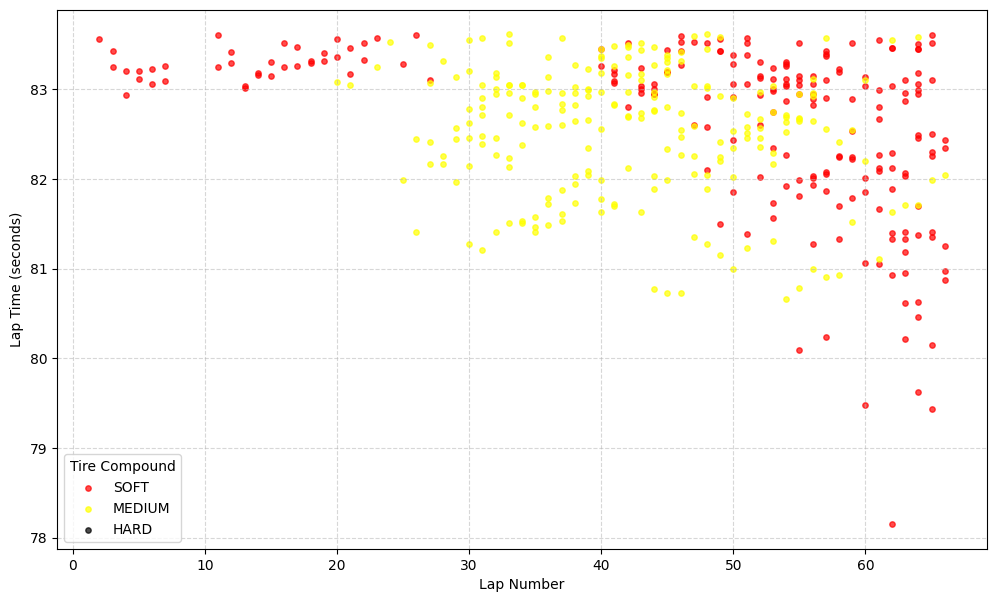

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'black'}

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    df = clean_laps[clean_laps['Compound'] == compound]
    
    ax.scatter(df['LapNumber'], df['LapTimeSec'], 
               color=compound_colors[compound], 
               label=compound, 
               s=15, 
               alpha=0.7)

ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(title="Tire Compound")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Conclusions

**Compound Performance Gap:** The Soft tires (Red) clearly provide the fastest initial lap times, sitting lower on the Y-axis. However, notice how the "cloud" of red dots ends early, showing their shorter lifespan.

**The Degradation Slope:** As the lap number increases, we see a general upward trend in lap times for the Mediums (Yellow). This is the "degradation" – the rubber wears out and the grip levels drop.

**Fuel Correction Effect:** A fascinating observation is the "dip" in times towards the end of the race (laps 60+). Even on older tires, the cars become faster because they are nearly empty of fuel, making the car significantly lighter.

**Strategy Outcome:** The data shows why the two-stop strategy was dominant; the pace drop-off on high-mileage tires (the upward climb of the dots) eventually makes a fresh set of tires much faster, even with the time lost in the pits.